In [1]:
# Title: "Image Classification Using Convolutional Neural Networks (CNN) on the MNIST Handwritten Digits Dataset"
# Dataset: "MNIST Handwritten Digits Dataset"

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


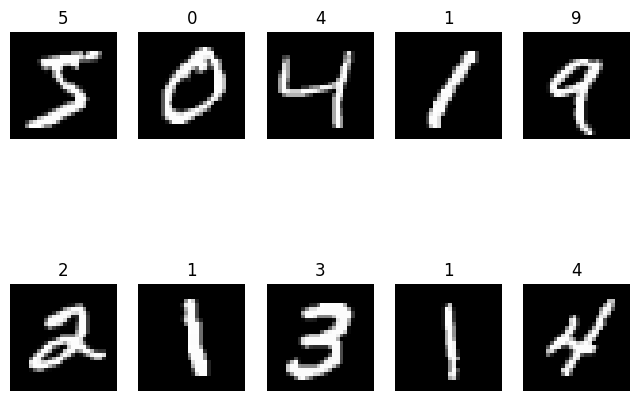

In [4]:
# Sample Images
plt.figure(figsize=(8,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(y_train[i])
  plt.axis("off")
plt.show()

In [5]:
# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
# Reshape Images
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [7]:
# One Hot Encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [8]:
# CNN Model Building
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Model Compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 56ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.0985 - loss: nan - val_accuracy: 0.0995 - val_loss: nan
Epoch 9/

In [ ]:
# Model Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [13]:
# Save Model
model.save("digit_cnn_model.h5")